# Create model for prediction of gamma shower

## Load modules and data

In [111]:
# import modules
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline 

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, validation_curve, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, make_scorer, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.base import clone

import optuna 
from optuna.samplers import TPESampler
import time

#from src.features import engineer_features

In [2]:
# ignore Data Conversion Warnings
from sklearn.exceptions import DataConversionWarning
import warnings
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

In [3]:
# show three digits
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.precision', 3)
np.set_printoptions(precision=3)

In [4]:
# set column names
columns = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
    "class"
]

# load data
df = pd.read_csv(
    r"../data/raw/magic04.data",
    header=None,
    names=columns
)

# remove dublicates before train-test-split
df = df.drop_duplicates().reset_index(drop=True)

# convert target from g/h --> 1/0
df["class"] = df["class"].map({
    "g": 1,   # gamma = signal
    "h": 0    # hadron = background
})

features = df.iloc[:, :-1]
target = df.iloc[:, -1]

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.1, random_state=42)

In [5]:
display(target_train)

15421    0
6829     1
11808    1
7765     1
12077    1
        ..
11284    1
11964    1
5390     1
860      1
15795    0
Name: class, Length: 17014, dtype: int64

In [6]:
# save features_test as 'features_test.csv'
features_train.to_csv(r'../data/raw/features_train_unprocessed.csv', index=False)

In [7]:
# save target_train as 'target_train.csv'
target_train.to_csv(r'../data/raw/target_train_unprocessed.csv', index=False)

In [8]:
# save features_test as 'features_test.csv'
features_test.to_csv(r'../data/raw/features_test_unprocessed.csv', index=False)

In [9]:
# save target_test as 'target_test.csv'
target_test.to_csv(r'../data/raw/target_test_unprocessed.csv', index=False)

## Scoring
Bei dem gegebenen Datensatz ist die accuracy als Gütemaß nicht aussagekräftig. Eine Klassifizierung eines Backround-Events als Gamma-Event ist hier viel schwerwiegender als eine fälschliche Klassifizierung eines Gamma-Events als Backround-Events.
Hier kommt es besonders darauf an, für verschiedene Grenzwerte 0.01, 0.02, 0.05, 0.1 und 0.2 (je nach Experiment) für die Wahrscheinlichkeit ein Backround-Event als Signal zu klassifizieren einen möglichst hohen Wert bei der ROC-Curve zu erhalten. Sieht man ein Gamma-Ereignis als Klasse  1 und ein Backround-Event als Klasse 0 an, so ergibt FPR (False Positiv Rate) den Anteil der Hadron-Ereignisse an, die fälschlicherweise als Gamma klassifiziert werden und TRP (True Positiv Rate / Recall) den Anteil der Gamma-Ereignisse, die korrekt als Gama identifiziert werden. Für die jeweiligen Grenzwerte der FPR, soll also die TPR (also die gamma-Effiezienz) möglichst groß werden. 
Für dieses Projekt wird deshalb ein eigenes Scoring definiert.
Als primäre Auswahlmetrik wird hier 5% verwendet, die anderen Metriken werden jedoch zusätzlich betrachtet

In [10]:
# true positiv rate at a given false positive rate, 0.05 as default
def tpr_at_fpr(target, target_pred, max_fpr=0.05):
    fpr, tpr, _ = roc_curve(target, target_pred)

    return np.max(tpr[fpr <= max_fpr])

In [11]:
# define scorer for different thresholds of fpr
scoring = {
    "roc_auc": "roc_auc",

    "tpr_fpr_001": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),   # use continouus model-score, if decision_function not supportet, use predict_proba
        max_fpr=0.01
    ),

    "tpr_fpr_002": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.02
    ),

    "tpr_fpr_005": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.05
    ),

    "tpr_fpr_010": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.10
    ),

    "tpr_fpr_020": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.20
    )
}


In diesem Notebook wird zunächst nur der scorer "tpr_fpr_020" verwendet

## Data Preparation

### Datatype transformation

Es ist keine weitere Umwandlung der Trainingsdaten notwendig (Umwandlung Target g/h --> 1/0 siehe oben)

### Data Imputation

Der Datensatz beinhaltet keine fehlenden Werte, es müssen also keine Daten imputiert werden

### Outlier
Der verwendete Datensatz beinhaltet keine unplausiblen Ausreißer. Alle in der univariaten Betrachtung auftretenden extremen Werte werden im Datensatz belassen, da sie in der multivariaten Betrachtung nicht auffällig sind

### Clean_data function

In [12]:
def clean_data(target):
    """
    Input: target to be changed to classes 1/0
    Output: cleaned target
    """
    # convert target from g/h --> 1/0
    target = target.map({
    "g": 1,   # gamma = signal
    "h": 0    # hadron = background
    })
  
    
    return target

### set cross-validation-parameter
Im folgenden wird immer wieder auf diese Definition zurückgegriffen

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


### Resampling

Da die Zielklassen mit etwa 65% (g) zu 35% (h) leicht unausgegleichen sind, wird über eine Kreuzvalidierung mit GridSearch ermittelt, welches Verfahren für diesen Datensatz am geeignetsten für ein Resampling ist

In [14]:
selected_features = features_train.columns   # use all columns

strategies = [   # combination of strategy name, sampling method and class_weights

    # No treatment of class imbalance
    (
        "baseline",
        "passthrough",
        None
    ),

    # Randomly duplicate minority-class observations
    (
        "oversampling",
        RandomOverSampler(random_state=42),
        None
    ),

    # Randomly remove majority-class observations
    (
        "undersampling",
        RandomUnderSampler(random_state=42),
        None
    ),

    # Handle imbalance through Logistic Regression itself
    (
        "class_weights",
        "passthrough",
        "balanced"
    ),

    # Generate synthetic minority observations
    (
        "SMOTE",
        SMOTE(random_state=42),
        None
    )
]


# ------------------------------------------------------------
# Hyperparameter search space
# ------------------------------------------------------------

param_grid = {
    "estimator__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}


# ------------------------------------------------------------
# GridSearch for every imbalance strategy
# ------------------------------------------------------------

results = []

best_models = {}

for name, sampler, class_weight in strategies:

    sampling_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "sampler",
            sampler
        ),
        (
            "estimator",
            LogisticRegression(
                solver="lbfgs",
                class_weight=class_weight,
                max_iter=1000,
                random_state=42
            )
        )
    ])
    grid_search = GridSearchCV(estimator = sampling_pipeline,
                              param_grid = param_grid,
                               cv = cv,
                              scoring = scoring["tpr_fpr_020"],
                              n_jobs = -1)
    grid_search.fit(features_train, target_train)
    model = grid_search.best_estimator_.named_steps['estimator']
    print(name)
    print(f"{grid_search.scoring} on Validationset: {grid_search.best_score_:.3f}")
    print(model)
    print('#'*11)

   



baseline
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.2) on Validationset: 0.724
LogisticRegression(C=0.001, max_iter=1000, random_state=42)
###########
oversampling
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.2) on Validationset: 0.737
LogisticRegression(C=1, max_iter=1000, random_state=42)
###########
undersampling
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.2) on Validationset: 0.735
LogisticRegression(C=0.01, max_iter=1000, random_state=42)
###########
class_weights
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.2) on Validationset: 0.737
LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   random_state=42)
###########
SMOTE
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.2) on Validationset: 0.735
LogisticRegression(C=0.1, max_iter=

Für alle Verfahren (baseline ausgenommen), zeigt sich ein sehr ähnlicher Score. Der Einfachheit halber wird deshalb class_weights='balanced' verwendet
 

## Baseline model
Als Baseline Modell wird eine einfache logistische Regression mit allen 10 ursprünglichen Features und ohne Sampling verwendet

In [15]:
# select baseline features
baseline_features = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist"
]

In [16]:
# instantiate model
log_reg = LogisticRegression(
    max_iter=10000,
    random_state=42
)

In [17]:
# build pipeline
log_reg_bl = Pipeline(steps = [('scaler', StandardScaler()), 
                                ('model', log_reg)])


In [18]:
# validate baseline model
cv_log_reg_bl = cross_val_score(estimator= log_reg_bl,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"])

print(f"CV best Score: {cv_log_reg_bl.mean():.3f}")


CV best Score: 0.721


In [19]:
model_names = []
model_names.append('logistische Regression Baseline')
files = []
cv_scores = []
cv_scores.append(cv_log_reg_bl.mean())


In [20]:
# fit pipeline 
log_reg_bl.fit(features_train, target_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](10,)","['fLength','fWidth','fSize',...,'fM3Trans','fAlpha','fDist']"
n_features_in_,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [21]:
pickle.dump(log_reg_bl, open('log_reg_bl.p', 'wb'))
files.append('log_reg_bl.p')

## Feature Engineering
Wie in der EDA bereits vorgestellt, gibt es einige inteessante neue Features, die aus den alten Features erstellt werden können

In [22]:
# Betrag der symmetrischen Features
features_train["abs_fAsym"] = features_train["fAsym"].abs()
features_train["abs_fM3Long"] = features_train["fM3Long"].abs()
features_train["abs_fM3Trans"] = features_train["fM3Trans"].abs()

In [23]:
# Längen-/Breitenverhältnis
features_train["width_length_ratio"] = features_train["fWidth"] / features_train["fLength"]


In [24]:
# Größe der Hillas-Ellipse
features_train["ellipse_area"] = features_train["fLength"] * features_train["fWidth"] * np.pi


In [25]:
# wie stark dominiert das hellste Pixel die beiden hellsten Pixel
features_train["brightest_pixel_share"] = features_train["fConc1"] / features_train["fConc"]

In [26]:
# Umwandlung von alpha vom Wertebereich 0 bis 90 auf 0 bis 1, 1 entspricht perfekte Ausrichtung zum Kamerazentrum
features_train["alpha_alignment"] = np.cos(np.deg2rad(features_train["fAlpha"]))

In [27]:
features_train.shape

(17014, 17)

In [28]:
def engineer_features(df):
    """
    Input: DataFrame
    Output: Dataframe
    creates new features
    """
    df = df.copy()
    
    # Betrag der symmetrischen Features
    df["abs_fAsym"] = df["fAsym"].abs()
    df["abs_fM3Long"] = df["fM3Long"].abs()
    df["abs_fM3Trans"] = df["fM3Trans"].abs()

    # Längen-/Breitenverhältnis
    df["width_length_ratio"] = df["fWidth"] / df["fLength"]

    # Größe der Hillas-Ellipse
    df["ellipse_area"] = df["fLength"] * df["fWidth"] * np.pi

    # wie stark dominiert das hellste Pixel die beiden hellsten Pixel
    df["brightest_pixel_share"] = df["fConc1"] / df["fConc"]

    # Umwandlung von alpha vom Wertebereich 0 bis 90 auf 0 bis 1, 1 entspricht perfekte Ausrichtung zum Kamerazentrum
    df["alpha_alignment"] = np.cos(np.deg2rad(df["fAlpha"]))

    return(df)

## Scaling
Da das Scaling wird später in die Pipeline integriert und hier deshalb nur instanziiert

In [29]:
scaler = StandardScaler()

## Logistische Regression
Als erstes Modell wird die logistische Regression betrachtet, zunächst ohne PCA, dann mit PCA. Im Anschluss wird mittels Bayesian Optimization eine Optimierung der Hyperparameter vorgenommen

In [30]:
# build unoptimized model

# instantiate model
log_reg = LogisticRegression(
    solver="lbfgs",  
    max_iter=10000,
    random_state=42,
    class_weight='balanced', 
    n_jobs=-1
)


# Instantiating final pipeline with preprocessor and model (logreg)
log_reg_pipe = Pipeline(steps = [('scaler', StandardScaler()), 
                                ('model', log_reg)])

cv_log_reg = cross_val_score(estimator= log_reg_pipe,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                            n_jobs=-1)

print(f"CV Score: {cv_log_reg.mean():.3f}")

CV Score: 0.768


zum Vergleich Ergebnis des Baseline Modells: 0.721
Durch Hinzunahme der neu erstellten Features deutliche Verbesserung der Modellgüte



In [31]:
model_names.append('Logistische Regression unoptimiert')
cv_scores.append(cv_log_reg.mean())

In [32]:
log_reg_pipe.fit(features_train, target_train)

c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](17,)","['fLength','fWidth','fSize',...,'ellipse_area','brightest_pixel_share', 'alpha_alignment']"
n_features_in_,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [33]:
pickle.dump(log_reg_pipe, open('log_reg.p', 'wb'))
files.append('log_reg.p')

In [34]:
# build unoptimized model with PCA

# instantiate model
log_reg = LogisticRegression(
    solver="lbfgs",  
    max_iter=10000,
    random_state=42,
    class_weight='balanced', 
    n_jobs=-1
)


# Instantiating final pipeline with preprocessor and model (logreg)
log_reg_pipe_PCA = Pipeline(steps = [('scaler', StandardScaler()), 
                                 ('PCA', PCA(n_components=0.95, random_state=42)),
                                ('model', log_reg)])

# validate baseline model
cv_log_reg_pca = cross_val_score(estimator= log_reg_pipe_PCA,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                            n_jobs=-1)

print(f"CV Score: {cv_log_reg_pca.mean():.3f}")

CV Score: 0.717


zum Vergleich ohne PCA: 0.768
Durch Hinzunahme der PCA deutliche Verschlechterung der Modellgüte 

In [35]:
model_names.append('Logistische Regression unoptimiert mit PCA')
cv_scores.append(cv_log_reg_pca.mean())

In [36]:
# fit pipeline 
log_reg_pipe_PCA.fit(features_train, np.ravel(target_train))

c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,steps,"[('scaler', ...), ('PCA', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](17,)","['fLength','fWidth','fSize',...,'ellipse_area','brightest_pixel_share', 'alpha_alignment']"
n_features_in_,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [37]:
pickle.dump(log_reg_pipe_PCA, open('log_reg_PCA.p', 'wb'))
files.append('log_reg_PCA.p')

In [38]:
# instantiate model for optimization
log_reg = LogisticRegression(
    solver="liblinear",  
    max_iter=10000,
    random_state=42,
    class_weight='balanced', 
    n_jobs=-1
)

# Instantiating pipeline for optimization
log_reg_pipe_opt = Pipeline(steps = [('scaler', StandardScaler()), 
                                 ('pca', PCA()),
                                ('model', log_reg)])


In [39]:
# tune hyperparameters with Bayesian Optimization

def objective_log_reg(trial):

    
    print(f"\n========== Trial {trial.number} ==========")
    
    # search space
    C = trial.suggest_float("C", 1e-4, 1000, log=True)        # inverse of regularization strength (small --> simple model)
    l1_ratio = trial.suggest_categorical("l1_ratio", [0.0, 1.0])   # 
    n_components = trial.suggest_int("n_components", 1, 17)   # PCA

    
    params_log_reg = {'model__C': C,
            'model__l1_ratio': l1_ratio,
            'pca__n_components': n_components,
            'model__max_iter' : 10000
            }
    
    log_reg_pipe_opt.set_params(**params_log_reg)

    
    # initiating cv
    score_log_reg =  cross_val_score(estimator=log_reg_pipe_opt, 
                             X=features_train, 
                             y=target_train, 
                             scoring=scoring["tpr_fpr_020"],
                             cv=cv,
                             n_jobs=-1).mean()
    
    print(f"CV fertig: {score_log_reg:.4f}")
    
    return score_log_reg

# create a study (aim to maximize score) und setting a seed (random_state) for reproduceability
study_log_reg = optuna.create_study(sampler=TPESampler(seed = 42), direction='maximize')

# perform hyperparamter tuning (while timing the process)
time_start = time.time()
# starting optimization process with our defined function and 50 iterations
study_log_reg.optimize(objective_log_reg, n_trials=50)   # more trial took to long for time limit
time_bayesian = time.time() - time_start

# store result in a data frame 
values_bayesian_log_reg = [50, study_log_reg.best_trial.number, study_log_reg.best_trial.value, time_bayesian]
results_bayesian_log_reg = pd.DataFrame([values_bayesian_log_reg], columns = ['Number of iterations', 
                                                                        'Iteration Number of Optimal Hyperparamters', 
                                                                        'Score', 
                                                                        'Time Elapsed (s)'])
        
          


[I 2026-09-28 14:49:49,793] A new study created in memory with name: no-name-2128a4d3-8141-48ec-8dfe-94acdb83650b



========== Trial 0 ==========
CV fertig: 0.7189


[I 2026-09-28 14:49:50,012] Trial 0 finished with value: 0.7188974618058361 and parameters: {'C': 0.041858227295469716, 'l1_ratio': 0.0, 'n_components': 11}. Best is trial 0 with value: 0.7188974618058361.
[I 2026-09-28 14:49:50,210] Trial 1 finished with value: 0.7275275240481771 and parameters: {'C': 0.0012363188277052211, 'l1_ratio': 0.0, 'n_components': 15}. Best is trial 1 with value: 0.7275275240481771.



========== Trial 1 ==========
CV fertig: 0.7275

========== Trial 2 ==========


[I 2026-09-28 14:49:50,515] Trial 2 finished with value: 0.7678010670115593 and parameters: {'C': 1.6136341713591311, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 2 with value: 0.7678010670115593.
[I 2026-09-28 14:49:50,672] Trial 3 finished with value: 0.701546681755719 and parameters: {'C': 67.1581131106993, 'l1_ratio': 0.0, 'n_components': 4}. Best is trial 2 with value: 0.7678010670115593.


CV fertig: 0.7678

========== Trial 3 ==========
CV fertig: 0.7015

========== Trial 4 ==========


[I 2026-09-28 14:49:50,827] Trial 4 finished with value: 0.7026252121897987 and parameters: {'C': 0.013480180290890806, 'l1_ratio': 0.0, 'n_components': 5}. Best is trial 2 with value: 0.7678010670115593.
[I 2026-09-28 14:49:50,980] Trial 5 finished with value: 0.7046032252849406 and parameters: {'C': 1.918537370384187, 'l1_ratio': 1.0, 'n_components': 7}. Best is trial 2 with value: 0.7678010670115593.


CV fertig: 0.7026

========== Trial 5 ==========
CV fertig: 0.7046

========== Trial 6 ==========


[I 2026-09-28 14:49:51,220] Trial 6 finished with value: 0.7184485086088432 and parameters: {'C': 0.15577217702693022, 'l1_ratio': 0.0, 'n_components': 9}. Best is trial 2 with value: 0.7678010670115593.


CV fertig: 0.7184

========== Trial 7 ==========


[I 2026-09-28 14:49:51,452] Trial 7 finished with value: 0.6750264327863552 and parameters: {'C': 1.4024971326600353, 'l1_ratio': 1.0, 'n_components': 3}. Best is trial 2 with value: 0.7678010670115593.


CV fertig: 0.6750

========== Trial 8 ==========


[I 2026-09-28 14:49:51,708] Trial 8 finished with value: 0.6731394390105893 and parameters: {'C': 0.00028533901052402264, 'l1_ratio': 1.0, 'n_components': 14}. Best is trial 2 with value: 0.7678010670115593.


CV fertig: 0.6731

========== Trial 9 ==========


[I 2026-09-28 14:49:51,978] Trial 9 finished with value: 0.7177286395602619 and parameters: {'C': 0.013561145768453494, 'l1_ratio': 1.0, 'n_components': 8}. Best is trial 2 with value: 0.7678010670115593.


CV fertig: 0.7177

========== Trial 10 ==========


[I 2026-09-28 14:49:52,403] Trial 10 finished with value: 0.723301592433918 and parameters: {'C': 60.534049645042224, 'l1_ratio': 0.0, 'n_components': 14}. Best is trial 2 with value: 0.7678010670115593.


CV fertig: 0.7233

========== Trial 11 ==========


[I 2026-09-28 14:49:52,732] Trial 11 finished with value: 0.6957030555331016 and parameters: {'C': 0.0001805149711156605, 'l1_ratio': 0.0, 'n_components': 14}. Best is trial 2 with value: 0.7678010670115593.


CV fertig: 0.6957

========== Trial 12 ==========


[I 2026-09-28 14:49:53,561] Trial 12 finished with value: 0.7678010670115593 and parameters: {'C': 6.009961010249739, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 2 with value: 0.7678010670115593.


CV fertig: 0.7678

========== Trial 13 ==========


[I 2026-09-28 14:49:54,272] Trial 13 finished with value: 0.7678909950691133 and parameters: {'C': 1.9770982971146283, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 13 with value: 0.7678909950691133.


CV fertig: 0.7679

========== Trial 14 ==========


[I 2026-09-28 14:49:54,639] Trial 14 finished with value: 0.716560706490987 and parameters: {'C': 201.1175037285344, 'l1_ratio': 0.0, 'n_components': 10}. Best is trial 13 with value: 0.7678909950691133.


CV fertig: 0.7166

========== Trial 15 ==========


[I 2026-09-28 14:49:55,219] Trial 15 finished with value: 0.7678010670115593 and parameters: {'C': 36.10312376918297, 'l1_ratio': 1.0, 'n_components': 17}. Best is trial 13 with value: 0.7678909950691133.


CV fertig: 0.7678

========== Trial 16 ==========


[I 2026-09-28 14:49:55,617] Trial 16 finished with value: 0.7614181957804542 and parameters: {'C': 0.12117784756958887, 'l1_ratio': 1.0, 'n_components': 15}. Best is trial 13 with value: 0.7678909950691133.


CV fertig: 0.7614

========== Trial 17 ==========


[I 2026-09-28 14:49:56,035] Trial 17 finished with value: 0.7239310484196914 and parameters: {'C': 0.7108545134926506, 'l1_ratio': 0.0, 'n_components': 12}. Best is trial 13 with value: 0.7678909950691133.


CV fertig: 0.7239

========== Trial 18 ==========


[I 2026-09-28 14:49:56,401] Trial 18 finished with value: 0.7177286799773663 and parameters: {'C': 27.806571872010206, 'l1_ratio': 1.0, 'n_components': 11}. Best is trial 13 with value: 0.7678909950691133.


CV fertig: 0.7177

========== Trial 19 ==========


[I 2026-09-28 14:49:56,856] Trial 19 finished with value: 0.7624969283000567 and parameters: {'C': 0.02050983586493678, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 13 with value: 0.7678909950691133.


CV fertig: 0.7625

========== Trial 20 ==========


[I 2026-09-28 14:49:57,436] Trial 20 finished with value: 0.7684306038315414 and parameters: {'C': 699.2478748126686, 'l1_ratio': 0.0, 'n_components': 16}. Best is trial 20 with value: 0.7684306038315414.


CV fertig: 0.7684

========== Trial 21 ==========


[I 2026-09-28 14:49:57,984] Trial 21 finished with value: 0.7678909546520087 and parameters: {'C': 205.628995659351, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 20 with value: 0.7684306038315414.


CV fertig: 0.7679

========== Trial 22 ==========


[I 2026-09-28 14:49:58,403] Trial 22 finished with value: 0.7683407161910921 and parameters: {'C': 684.8971220683679, 'l1_ratio': 1.0, 'n_components': 16}. Best is trial 20 with value: 0.7684306038315414.


CV fertig: 0.7683

========== Trial 23 ==========


[I 2026-09-28 14:49:58,691] Trial 23 finished with value: 0.7232117047934685 and parameters: {'C': 299.8404237399103, 'l1_ratio': 1.0, 'n_components': 14}. Best is trial 20 with value: 0.7684306038315414.


CV fertig: 0.7232

========== Trial 24 ==========


[I 2026-09-28 14:49:58,960] Trial 24 finished with value: 0.723211502707946 and parameters: {'C': 1.3870123936557546, 'l1_ratio': 1.0, 'n_components': 13}. Best is trial 20 with value: 0.7684306038315414.


CV fertig: 0.7232

========== Trial 25 ==========


[I 2026-09-28 14:49:59,389] Trial 25 finished with value: 0.7622273057958129 and parameters: {'C': 6.365177104014377, 'l1_ratio': 0.0, 'n_components': 15}. Best is trial 20 with value: 0.7684306038315414.


CV fertig: 0.7622

========== Trial 26 ==========


[I 2026-09-28 14:49:59,704] Trial 26 finished with value: 0.7232114622908414 and parameters: {'C': 778.5902985898093, 'l1_ratio': 0.0, 'n_components': 13}. Best is trial 20 with value: 0.7684306038315414.


CV fertig: 0.7232

========== Trial 27 ==========


[I 2026-09-28 14:50:00,092] Trial 27 finished with value: 0.768520491471991 and parameters: {'C': 859.9521126161015, 'l1_ratio': 0.0, 'n_components': 16}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7685

========== Trial 28 ==========


[I 2026-09-28 14:50:00,412] Trial 28 finished with value: 0.7683407161910921 and parameters: {'C': 647.3496565050298, 'l1_ratio': 1.0, 'n_components': 16}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7683

========== Trial 29 ==========


[I 2026-09-28 14:50:00,640] Trial 29 finished with value: 0.70469311292539 and parameters: {'C': 102.57798705898942, 'l1_ratio': 1.0, 'n_components': 7}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7047

========== Trial 30 ==========


[I 2026-09-28 14:50:00,913] Trial 30 finished with value: 0.716560706490987 and parameters: {'C': 20.12481245168855, 'l1_ratio': 0.0, 'n_components': 10}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7166

========== Trial 31 ==========


[I 2026-09-28 14:50:01,348] Trial 31 finished with value: 0.7678010670115593 and parameters: {'C': 710.9637172393664, 'l1_ratio': 1.0, 'n_components': 17}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7678

========== Trial 32 ==========


[I 2026-09-28 14:50:01,611] Trial 32 finished with value: 0.7624970899684748 and parameters: {'C': 30.692119606421038, 'l1_ratio': 1.0, 'n_components': 15}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7625

========== Trial 33 ==========


[I 2026-09-28 14:50:01,861] Trial 33 finished with value: 0.7242007113410395 and parameters: {'C': 429.26044608955, 'l1_ratio': 1.0, 'n_components': 12}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7242

========== Trial 34 ==========


[I 2026-09-28 14:50:02,279] Trial 34 finished with value: 0.768340716191092 and parameters: {'C': 622.4132760120469, 'l1_ratio': 0.0, 'n_components': 16}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7683

========== Trial 35 ==========


[I 2026-09-28 14:50:02,711] Trial 35 finished with value: 0.7678010670115593 and parameters: {'C': 130.8713268197811, 'l1_ratio': 1.0, 'n_components': 17}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7678

========== Trial 36 ==========


[I 2026-09-28 14:50:02,988] Trial 36 finished with value: 0.7624970899684748 and parameters: {'C': 822.2243769901656, 'l1_ratio': 1.0, 'n_components': 15}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7625

========== Trial 37 ==========


[I 2026-09-28 14:50:03,298] Trial 37 finished with value: 0.7683407161910921 and parameters: {'C': 3.834893235759843, 'l1_ratio': 1.0, 'n_components': 16}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7683

========== Trial 38 ==========


[I 2026-09-28 14:50:03,572] Trial 38 finished with value: 0.7242007113410395 and parameters: {'C': 74.46011854985471, 'l1_ratio': 0.0, 'n_components': 12}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7242

========== Trial 39 ==========


[I 2026-09-28 14:50:03,944] Trial 39 finished with value: 0.7678909546520087 and parameters: {'C': 37.83840232520417, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7679

========== Trial 40 ==========


[I 2026-09-28 14:50:04,185] Trial 40 finished with value: 0.716560706490987 and parameters: {'C': 338.37745383791486, 'l1_ratio': 1.0, 'n_components': 10}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7166

========== Trial 41 ==========


[I 2026-09-28 14:50:04,490] Trial 41 finished with value: 0.7674415568668661 and parameters: {'C': 0.07101869051192324, 'l1_ratio': 1.0, 'n_components': 17}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7674

========== Trial 42 ==========


[I 2026-09-28 14:50:04,756] Trial 42 finished with value: 0.723301592433918 and parameters: {'C': 216.14880907950587, 'l1_ratio': 0.0, 'n_components': 14}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7233

========== Trial 43 ==========


[I 2026-09-28 14:50:05,093] Trial 43 finished with value: 0.7683406757739875 and parameters: {'C': 2.0948995801094377, 'l1_ratio': 1.0, 'n_components': 16}. Best is trial 27 with value: 0.768520491471991.
[I 2026-09-28 14:50:05,280] Trial 44 finished with value: 0.0 and parameters: {'C': 0.00015486652901998974, 'l1_ratio': 1.0, 'n_components': 16}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7683

========== Trial 44 ==========
CV fertig: 0.0000

========== Trial 45 ==========


[I 2026-09-28 14:50:05,484] Trial 45 finished with value: 0.7152108964513783 and parameters: {'C': 0.0033200910948854457, 'l1_ratio': 1.0, 'n_components': 17}. Best is trial 27 with value: 0.768520491471991.
[I 2026-09-28 14:50:05,682] Trial 46 finished with value: 0.7251000727507881 and parameters: {'C': 0.00614344164578962, 'l1_ratio': 1.0, 'n_components': 15}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7152

========== Trial 46 ==========
CV fertig: 0.7251

========== Trial 47 ==========


[I 2026-09-28 14:50:05,893] Trial 47 finished with value: 0.723301592433918 and parameters: {'C': 8.147896715482602, 'l1_ratio': 1.0, 'n_components': 14}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7233

========== Trial 48 ==========


[I 2026-09-28 14:50:06,260] Trial 48 finished with value: 0.7684306038315414 and parameters: {'C': 81.43147353086842, 'l1_ratio': 0.0, 'n_components': 16}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7684

========== Trial 49 ==========


[I 2026-09-28 14:50:06,586] Trial 49 finished with value: 0.7622271441273947 and parameters: {'C': 1.6613380569504845, 'l1_ratio': 0.0, 'n_components': 15}. Best is trial 27 with value: 0.768520491471991.


CV fertig: 0.7622


In [40]:
# Ausgabe des Ergebnisses
results_bayesian_log_reg

,Number of iterations,Iteration Number of Optimal Hyperparamters,Score,Time Elapsed (s)
0,50,27,0.769,16.786


In [41]:
# Ausgabe der besten Parameter
study_log_reg.best_params

{'C': 859.9521126161015, 'l1_ratio': 0.0, 'n_components': 16}

In [42]:
best_params_log_reg = study_log_reg.best_params
log_reg_pipe_bo = log_reg_pipe_opt.set_params(
            model__C=best_params_log_reg["C"],
            model__l1_ratio=best_params_log_reg["l1_ratio"],
            pca__n_components=best_params_log_reg["n_components"]
)

In [43]:
cv_log_reg_bo = cross_val_score(estimator= log_reg_pipe_bo,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                            n_jobs=-1)
#print(cv_log_reg_bo.mean())
print(f"CV Score: {cv_log_reg_bo.mean():.3f}")

CV Score: 0.769


zum Vergleich ohne Optimierung ohne PCA: 0.768

ohne Optimierung mit PCA: 0.717

nur minimale Verbesserung durch Optimierung

In [44]:
model_names.append('Logistische Regression optimiert')
cv_scores.append(cv_log_reg_bo.mean())

In [45]:
log_reg_pipe_bo.fit(features_train, target_train)

c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](17,)","['fLength','fWidth','fSize',...,'ellipse_area','brightest_pixel_share', 'alpha_alignment']"
n_features_in_,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [46]:
pickle.dump(log_reg_pipe_bo, open('log_reg_opt.p', 'wb'))
files.append('log_reg_opt.p')

## Support Vektor Machine
In EDA mehrere nichtlineare Zusammenhänge entdeckt, deshalb SVM besonders interessant

In [47]:
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        random_state=42
    ))
])

In [48]:
cv_svm = cross_val_score(estimator= svm_pipe,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                            n_jobs=-1)

print(f"CV Score: {cv_svm.mean():.3f}")

CV Score: 0.907


Zum Vergleich Baseline Modell: 0.721
leichte Verschlechterung im Vergleich zum Baseline Modell

In [49]:
model_names.append('Support Vector Machine unoptimiert')
cv_scores.append(cv_svm.mean())

In [50]:
svm_pipe.fit(features_train, target_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](17,)","['fLength','fWidth','fSize',...,'ellipse_area','brightest_pixel_share', 'alpha_alignment']"
n_features_in_,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [51]:
pickle.dump(svm_pipe, open('svm_simple.p', 'wb'))
files.append('svm_simple.p')

In [52]:
svm_pipe_opt = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", SVC(
        kernel="rbf",
        random_state=42
    ))
])

In [53]:
# tune hyperparameters with Bayesian Optimization

def objective_svm(trial):

    
    print(f"\n========== Trial {trial.number} ==========")
    
    # search space
    C = trial.suggest_float("C", 1e-3, 1000, log=True)        # steuert Trade-Off zwischen einfacher Entscheidungsgrenze und möglichst wenig Trainingsfehlern
    gamma = trial.suggest_float("gamma", 1e-4, 1e1, log=True)   #  bestimmt wie lokal der Einfluss eines einzelnen Trainingspunkts ist
    n_components = trial.suggest_int("n_components", 1, 17)   # PCA  

    
    params_svm = {'model__C': C,
            'model__gamma': gamma,
            'pca__n_components': n_components,
            'model__max_iter' : 10000
            }
    
    svm_pipe_opt.set_params(**params_svm)

    
    # initiating cv
    score_svm =  cross_val_score(estimator=svm_pipe_opt, 
                             X=features_train, 
                             y=target_train, 
                             scoring=scoring["tpr_fpr_020"],
                             cv=cv,
                             n_jobs=-1).mean()
    
    print(f"CV fertig: {score_svm:.4f}")
    
    return score_svm

# create a study (aim to maximize score) und setting a seed (random_state) for reproduceability
study_svm = optuna.create_study(sampler=TPESampler(seed = 42), direction='maximize')

# perform hyperparamter tuning (while timing the process)
time_start = time.time()
# starting optimization process with our defined function and 50 iterations
study_svm.optimize(objective_svm, n_trials=50)   # more trial took to long for time limit
time_bayesian = time.time() - time_start

# store result in a data frame 
values_bayesian_svm = [50, study_svm.best_trial.number, study_svm.best_trial.value, time_bayesian]
results_bayesian_svm = pd.DataFrame([values_bayesian_svm], columns = ['Number of iterations', 
                                                                        'Iteration Number of Optimal Hyperparamters', 
                                                                        'Score', 
                                                                        'Time Elapsed (s)'])
        
          


[I 2026-09-28 14:51:08,841] A new study created in memory with name: no-name-5a5e3d69-7860-42b0-91ae-a023231a39c2



========== Trial 0 ==========


[I 2026-09-28 14:52:36,640] Trial 0 finished with value: 0.8178714331905261 and parameters: {'C': 0.1767016940294795, 'gamma': 5.669849511478847, 'n_components': 13}. Best is trial 0 with value: 0.8178714331905261.


CV fertig: 0.8179

========== Trial 1 ==========


[I 2026-09-28 14:53:08,069] Trial 1 finished with value: 0.6851851911729043 and parameters: {'C': 3.907967156822881, 'gamma': 0.0006026889128682511, 'n_components': 3}. Best is trial 0 with value: 0.8178714331905261.


CV fertig: 0.6852

========== Trial 2 ==========


[I 2026-09-28 14:54:04,256] Trial 2 finished with value: 0.8211991350739634 and parameters: {'C': 0.002231010801867922, 'gamma': 2.1423021757741068, 'n_components': 11}. Best is trial 2 with value: 0.8211991350739634.


CV fertig: 0.8212

========== Trial 3 ==========


[I 2026-09-28 14:54:51,556] Trial 3 finished with value: 0.7568335219464878 and parameters: {'C': 17.71884735480682, 'gamma': 0.00012674255898937226, 'n_components': 17}. Best is trial 2 with value: 0.8211991350739634.


CV fertig: 0.7568

========== Trial 4 ==========


[I 2026-09-28 14:55:24,025] Trial 4 finished with value: 0.7781360035567051 and parameters: {'C': 98.77700294007911, 'gamma': 0.0011526449540315614, 'n_components': 4}. Best is trial 2 with value: 0.8211991350739634.


CV fertig: 0.7781

========== Trial 5 ==========


[I 2026-09-28 14:56:12,138] Trial 5 finished with value: 0.6950742058038962 and parameters: {'C': 0.012601639723276799, 'gamma': 0.0033205591037519565, 'n_components': 9}. Best is trial 2 with value: 0.8211991350739634.


CV fertig: 0.6951

========== Trial 6 ==========


[I 2026-09-28 14:56:54,981] Trial 6 finished with value: 0.7590790558564384 and parameters: {'C': 0.3905441275210791, 'gamma': 0.0028585493941961923, 'n_components': 11}. Best is trial 2 with value: 0.8211991350739634.


CV fertig: 0.7591

========== Trial 7 ==========


[I 2026-09-28 14:57:41,020] Trial 7 finished with value: 0.6463497696225042 and parameters: {'C': 0.006870101665590026, 'gamma': 0.0028888383623653178, 'n_components': 7}. Best is trial 2 with value: 0.8211991350739634.


CV fertig: 0.6463

========== Trial 8 ==========


[I 2026-09-28 14:58:13,953] Trial 8 finished with value: 0.7908142025705278 and parameters: {'C': 0.5450293694558254, 'gamma': 0.8431013932082461, 'n_components': 4}. Best is trial 2 with value: 0.8211991350739634.


CV fertig: 0.7908

========== Trial 9 ==========


[I 2026-09-28 14:58:52,230] Trial 9 finished with value: 0.28236262226174114 and parameters: {'C': 1.2173252504194043, 'gamma': 0.09163741808778776, 'n_components': 1}. Best is trial 2 with value: 0.8211991350739634.


CV fertig: 0.2824

========== Trial 10 ==========


[I 2026-09-28 14:59:34,073] Trial 10 finished with value: 0.6476096516045591 and parameters: {'C': 0.0017418301536324362, 'gamma': 3.448286794348852, 'n_components': 2}. Best is trial 2 with value: 0.8211991350739634.


CV fertig: 0.6476

========== Trial 11 ==========


[I 2026-09-28 15:00:52,430] Trial 11 finished with value: 0.8593142429876324 and parameters: {'C': 0.05272254971726053, 'gamma': 1.9061369877430585, 'n_components': 14}. Best is trial 11 with value: 0.8593142429876324.


CV fertig: 0.8593

========== Trial 12 ==========


[I 2026-09-28 15:01:17,676] Trial 12 finished with value: 0.9060601406515237 and parameters: {'C': 2.429928164818416, 'gamma': 0.3150253641280958, 'n_components': 15}. Best is trial 12 with value: 0.9060601406515237.


CV fertig: 0.9061

========== Trial 13 ==========


[I 2026-09-28 15:01:41,255] Trial 13 finished with value: 0.9025544014226821 and parameters: {'C': 0.343960007793184, 'gamma': 0.18389929816205444, 'n_components': 15}. Best is trial 12 with value: 0.9060601406515237.


CV fertig: 0.9026

========== Trial 14 ==========


[I 2026-09-28 15:02:00,760] Trial 14 finished with value: 0.898777665508043 and parameters: {'C': 5.7716750162739014, 'gamma': 0.3135909851490368, 'n_components': 13}. Best is trial 12 with value: 0.9060601406515237.


CV fertig: 0.8988

========== Trial 15 ==========


[I 2026-09-28 15:02:22,913] Trial 15 finished with value: 0.9064194487106942 and parameters: {'C': 0.8733879424731184, 'gamma': 0.3029454672697699, 'n_components': 17}. Best is trial 15 with value: 0.9064194487106942.


CV fertig: 0.9064

========== Trial 16 ==========


[I 2026-09-28 15:02:47,914] Trial 16 finished with value: 0.8086120362137258 and parameters: {'C': 0.02341051170181343, 'gamma': 0.033005090527517385, 'n_components': 17}. Best is trial 15 with value: 0.9064194487106942.


CV fertig: 0.8086

========== Trial 17 ==========


[I 2026-09-28 15:03:04,767] Trial 17 finished with value: 0.9082171611025787 and parameters: {'C': 6.70465206569755, 'gamma': 0.2074192088418172, 'n_components': 17}. Best is trial 17 with value: 0.9082171611025787.


CV fertig: 0.9082

========== Trial 18 ==========


[I 2026-09-28 15:03:21,342] Trial 18 finished with value: 0.9083079783364318 and parameters: {'C': 34.92418146251849, 'gamma': 0.11108527761953839, 'n_components': 17}. Best is trial 18 with value: 0.9083079783364318.


CV fertig: 0.9083

========== Trial 19 ==========


[I 2026-09-28 15:03:36,096] Trial 19 finished with value: 0.8154466090049309 and parameters: {'C': 113.24454304709094, 'gamma': 0.0996868220543728, 'n_components': 15}. Best is trial 18 with value: 0.9083079783364318.


CV fertig: 0.8154

========== Trial 20 ==========


[I 2026-09-28 15:04:08,303] Trial 20 finished with value: 0.8576052461401666 and parameters: {'C': 285.29725472402583, 'gamma': 1.42343803466473, 'n_components': 17}. Best is trial 18 with value: 0.9083079783364318.


CV fertig: 0.8576

========== Trial 21 ==========


[I 2026-09-28 15:04:41,291] Trial 21 finished with value: 0.8490651523724839 and parameters: {'C': 42.656464756298455, 'gamma': 1.8814784697837261, 'n_components': 14}. Best is trial 18 with value: 0.9083079783364318.


CV fertig: 0.8491

========== Trial 22 ==========


[I 2026-09-28 15:04:54,697] Trial 22 finished with value: 0.9097458976638914 and parameters: {'C': 39.23198725052983, 'gamma': 0.018203824396691222, 'n_components': 13}. Best is trial 22 with value: 0.9097458976638914.


CV fertig: 0.9097

========== Trial 23 ==========


[I 2026-09-28 15:05:08,881] Trial 23 finished with value: 0.850594373939051 and parameters: {'C': 38.99369512125251, 'gamma': 0.0217018329649958, 'n_components': 10}. Best is trial 22 with value: 0.9097458976638914.


CV fertig: 0.8506

========== Trial 24 ==========


[I 2026-09-28 15:05:21,755] Trial 24 finished with value: 0.9102851830894835 and parameters: {'C': 16.76975144155198, 'gamma': 0.011657528963937536, 'n_components': 17}. Best is trial 24 with value: 0.9102851830894835.


CV fertig: 0.9103

========== Trial 25 ==========


[I 2026-09-28 15:05:34,629] Trial 25 finished with value: 0.4885995877455339 and parameters: {'C': 991.230443181406, 'gamma': 0.009207424743031744, 'n_components': 17}. Best is trial 24 with value: 0.9102851830894835.


CV fertig: 0.4886

========== Trial 26 ==========


[I 2026-09-28 15:05:48,109] Trial 26 finished with value: 0.8861929916740763 and parameters: {'C': 2.736209882952849, 'gamma': 0.007118504140674008, 'n_components': 16}. Best is trial 24 with value: 0.9102851830894835.


CV fertig: 0.8862

========== Trial 27 ==========


[I 2026-09-28 15:06:01,199] Trial 27 finished with value: 0.8952730175410233 and parameters: {'C': 18.659329319642712, 'gamma': 0.005050343871629941, 'n_components': 15}. Best is trial 24 with value: 0.9102851830894835.


CV fertig: 0.8953

========== Trial 28 ==========


[I 2026-09-28 15:06:13,672] Trial 28 finished with value: 0.7066729447902352 and parameters: {'C': 597.8208530167503, 'gamma': 0.0037996240004692975, 'n_components': 11}. Best is trial 24 with value: 0.9102851830894835.


CV fertig: 0.7067

========== Trial 29 ==========


[I 2026-09-28 15:06:26,816] Trial 29 finished with value: 0.9154092636003558 and parameters: {'C': 31.22110840415006, 'gamma': 0.022056943578127004, 'n_components': 17}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.9154

========== Trial 30 ==========


[I 2026-09-28 15:06:41,583] Trial 30 finished with value: 0.9057895077196669 and parameters: {'C': 46.37347286818624, 'gamma': 0.02619748987831898, 'n_components': 14}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.9058

========== Trial 31 ==========


[I 2026-09-28 15:06:54,742] Trial 31 finished with value: 0.9063304502465444 and parameters: {'C': 58.672037094962896, 'gamma': 0.01862807805768355, 'n_components': 17}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.9063

========== Trial 32 ==========


[I 2026-09-28 15:07:07,190] Trial 32 finished with value: 0.8474481448549026 and parameters: {'C': 6.015045996846647, 'gamma': 0.11535612160716602, 'n_components': 9}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.8474

========== Trial 33 ==========


[I 2026-09-28 15:07:19,348] Trial 33 finished with value: 0.7223054724759519 and parameters: {'C': 237.45214634201392, 'gamma': 0.019253989735968806, 'n_components': 15}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.7223

========== Trial 34 ==========


[I 2026-09-28 15:07:31,897] Trial 34 finished with value: 0.9056107428663809 and parameters: {'C': 6.541686501908214, 'gamma': 0.015682633627718847, 'n_components': 13}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.9056

========== Trial 35 ==========


[I 2026-09-28 15:07:46,594] Trial 35 finished with value: 0.897969848840029 and parameters: {'C': 200.58149255484005, 'gamma': 0.0023300241459178555, 'n_components': 15}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.8980

========== Trial 36 ==========


[I 2026-09-28 15:08:00,381] Trial 36 finished with value: 0.8749559049389702 and parameters: {'C': 106.9865389645006, 'gamma': 0.0009836652672886598, 'n_components': 12}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.8750

========== Trial 37 ==========


[I 2026-09-28 15:08:15,943] Trial 37 finished with value: 0.7984546924258347 and parameters: {'C': 3.816348665215729, 'gamma': 0.0011217257319461487, 'n_components': 14}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.7985

========== Trial 38 ==========


[I 2026-09-28 15:08:28,391] Trial 38 finished with value: 0.5504310888367957 and parameters: {'C': 469.38714191266405, 'gamma': 0.06304858014467206, 'n_components': 17}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.5504

========== Trial 39 ==========


[I 2026-09-28 15:08:40,362] Trial 39 finished with value: 0.9113642389459219 and parameters: {'C': 5.279700421514012, 'gamma': 0.030213247175920166, 'n_components': 17}. Best is trial 29 with value: 0.9154092636003558.


CV fertig: 0.9114

========== Trial 40 ==========


[I 2026-09-28 15:08:53,350] Trial 40 finished with value: 0.9157685312424219 and parameters: {'C': 17.033881600712867, 'gamma': 0.04402725017995011, 'n_components': 16}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.9158

========== Trial 41 ==========


[I 2026-09-28 15:09:05,937] Trial 41 finished with value: 0.9138812545469243 and parameters: {'C': 11.515319192189287, 'gamma': 0.028294610611206337, 'n_components': 16}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.9139

========== Trial 42 ==========


[I 2026-09-28 15:09:18,773] Trial 42 finished with value: 0.9130723466170882 and parameters: {'C': 7.675062221030576, 'gamma': 0.03134589869956912, 'n_components': 17}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.9131

========== Trial 43 ==========


[I 2026-09-28 15:09:31,871] Trial 43 finished with value: 0.9145100638590252 and parameters: {'C': 19.427405359181158, 'gamma': 0.04736766833723112, 'n_components': 14}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.9145

========== Trial 44 ==========


[I 2026-09-28 15:09:44,050] Trial 44 finished with value: 0.9130718211947295 and parameters: {'C': 7.457801541397337, 'gamma': 0.05096658946841794, 'n_components': 13}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.9131

========== Trial 45 ==========


[I 2026-09-28 15:09:57,975] Trial 45 finished with value: 0.8801697114218736 and parameters: {'C': 0.5146514736057909, 'gamma': 0.01493670303612556, 'n_components': 15}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.8802

========== Trial 46 ==========


[I 2026-09-28 15:10:10,356] Trial 46 finished with value: 0.8835847546681755 and parameters: {'C': 24.345492547430634, 'gamma': 0.23707161669587176, 'n_components': 14}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.8836

========== Trial 47 ==========


[I 2026-09-28 15:10:23,318] Trial 47 finished with value: 0.8960816425511278 and parameters: {'C': 1.1836318877809409, 'gamma': 0.016729327418665417, 'n_components': 17}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.8961

========== Trial 48 ==========


[I 2026-09-28 15:10:39,352] Trial 48 finished with value: 0.8472670358095546 and parameters: {'C': 31.125442360265122, 'gamma': 0.5547469927348738, 'n_components': 17}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.8473

========== Trial 49 ==========


[I 2026-09-28 15:10:51,257] Trial 49 finished with value: 0.9014756284859754 and parameters: {'C': 0.5930817921680726, 'gamma': 0.03905072959094763, 'n_components': 16}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.9015


In [54]:
# Ausgabe des Ergebnisses
results_bayesian_svm

,Number of iterations,Iteration Number of Optimal Hyperparamters,Score,Time Elapsed (s)
0,50,40,0.916,"1,182.433"


In [55]:
# Ausgabe der besten Parameter
study_svm.best_params

{'C': 17.033881600712867, 'gamma': 0.04402725017995011, 'n_components': 16}

In [56]:
best_params_svm = study_svm.best_params
svm_pipe_bo = svm_pipe_opt.set_params(
            model__C=best_params_svm["C"],
            model__gamma=best_params_svm["gamma"],
            pca__n_components=best_params_svm["n_components"]
)

In [57]:
cv_svm_bo = cross_val_score(estimator= svm_pipe_bo,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                            n_jobs=-1)
#print(cv_log_reg_bo.mean())
print(f"CV Score: {cv_svm_bo.mean():.3f}")

CV Score: 0.916


Zum Vergleich ohne Optimierung: 0.717

optimiertes Logistische Regession-Modell: 0.769

Damit ist die optimierte Support Vektor Machine das bisher interessanteste Modell. Die Optimierung hat eine deutliche Verbesserung gegenüber dem einfachen Modell gebracht

In [58]:
model_names.append('Support Vector Machine optimiert')
cv_scores.append(cv_svm_bo.mean())

In [59]:
# fit optimized pipeline to trainset
svm_pipe_bo.fit(features_train, target_train)

c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\svm\_base.py:337: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](17,)","['fLength','fWidth','fSize',...,'ellipse_area','brightest_pixel_share', 'alpha_alignment']"
n_features_in_,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [60]:
# save optimized pipeline as pickle
pickle.dump(svm_pipe_bo, open('svm_opt.p', 'wb'))
files.append('svm_opt.p')

## Random Forrest

In [61]:
# build unoptimized model

# instantiate model
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)


# Instantiating final pipeline, no need for scaling or PCA in RandomForest
rf_pipe = model_rf
cv_rf = cross_val_score(estimator= rf_pipe,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                           n_jobs=-1)
#print(cv_rf.mean())
print(f"CV Score: {cv_rf.mean():.3f}")

CV Score: 0.917


Zum Vergleich:
Baseline: 0.721
unoptimierte logostische Regression: 0.768
unoptimierte SVM: 0.717

In [62]:
model_names.append('Random Forest unoptimiert')
cv_scores.append(cv_rf.mean())

In [63]:
# fit pipeline to trainset
rf_pipe.fit(features_train, target_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [64]:
# save fitted pipeline as pickle
pickle.dump(rf_pipe, open('rf_simple.p', 'wb'))
files.append('rf_simple.p')

In [65]:
# optimize model with bayesian optimization
def objective_rf(trial):
    """return maximized f1-score"""
   
    # search space
    n_estimators = trial.suggest_int("n_estimators", 50, 250, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 15)  
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10, step=2)   
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 3,10, step=1)   
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    
    params_rf = {"n_estimators": n_estimators,
                'max_depth': max_depth,
              'min_samples_split': min_samples_split,
             'min_samples_leaf': min_samples_leaf,
              'max_features': max_features
            }
    rf_pipe.set_params(**params_rf)

    
    # initiating cv
    score_rf =  cross_val_score(estimator=rf_pipe, 
                             X=features_train, 
                             y=target_train, 
                             scoring=scoring["tpr_fpr_020"],
                             cv=cv,
                             n_jobs=-1).mean()
    
    return score_rf

# create a study (aim to maximize score) und setting a seed (random_state) for reproduceability
study_rf = optuna.create_study(sampler=TPESampler(seed = 42), direction='maximize')

# perform hyperparamter tuning (while timing the process)
time_start = time.time()
# starting optimization process with our defined function and 50 iterations
study_rf.optimize(objective_rf, n_trials=50)
time_bayesian = time.time() - time_start

# store result in a data frame 
values_bayesian_rf = [50, study_rf.best_trial.number, study_rf.best_trial.value, time_bayesian]
results_bayesian_rf = pd.DataFrame([values_bayesian_rf], columns = ['Number of iterations', 
                                                                        'Iteration Number of Optimal Hyperparamters', 
                                                                        'Score', 
                                                                        'Time Elapsed (s)'])

[I 2026-09-28 15:11:30,341] A new study created in memory with name: no-name-dfd63d05-2ebd-4784-ba51-a6ce3e0005cb
[I 2026-09-28 15:11:39,807] Trial 0 finished with value: 0.9206230296661548 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9206230296661548.
[I 2026-09-28 15:11:43,991] Trial 1 finished with value: 0.9170266348718779 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.9206230296661548.
[I 2026-09-28 15:11:58,046] Trial 2 finished with value: 0.8833142429876324 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9206230296661548.
[I 2026-09-28 15:12:07,276] Trial 3 finished with value: 0.8951805432058848 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_

In [66]:
# Ausgabe des Ergebnisses
results_bayesian_rf

,Number of iterations,Iteration Number of Optimal Hyperparamters,Score,Time Elapsed (s)
0,50,34,0.927,608.859


In [67]:
# Ausgabe der besten Parameter
study_rf.best_params

{'n_estimators': 200,
 'max_depth': 14,
 'min_samples_split': 2,
 'min_samples_leaf': 3,
 'max_features': 'log2'}

In [68]:
best_params_rf = study_rf.best_params
rf_pipe_bo = rf_pipe.set_params(
            n_estimators=best_params_rf["n_estimators"],
            max_depth=best_params_rf["max_depth"],
            min_samples_split=best_params_rf["min_samples_split"],
            min_samples_leaf=best_params_rf["min_samples_leaf"],
            max_features=best_params_rf["max_features"]
)


In [69]:
cv_rf_bo = cross_val_score(estimator= rf_pipe_bo,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                            n_jobs=-1)
#print(cv_log_reg_bo.mean())
print(f"CV Score: {cv_rf_bo.mean():.3f}")

CV Score: 0.927


Zum Vergleich: 

RandomForest ohne Optimierung: 0.917

optimierte logistische Regression: 0.769

optminierte SVM: 0.916

leichte Verbesserung gegenüber unoptimiertem Modell und optimierter SVM, bisher bestes Modell

In [70]:
model_names.append('Random Forest optimiert')
cv_scores.append(cv_rf_bo.mean())

In [71]:
# fit optimized pipeline to trainset
rf_pipe_bo.fit(features_train, target_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for frac

In [72]:
# save optimized pipeline as pickle
pickle.dump(rf_pipe_bo, open('rf_opt.p', 'wb'))
files.append('rf_opt.p')

## Einfaches neuronales Netz 
Für eher kleineren Datensatz wird zunächst einfaches neuronales Netz aus sklearn verwendet, um zu prüfen, ob ein neuronales Netz für dieses Projekt vielversprechend ist

In [73]:
# build unoptimized model

# instantiate model
model_nn = MLPClassifier(
        hidden_layer_sizes=(32, 16),   # zwei hidden layer, 1. mit  32 dann mit 16 
        activation="relu",             # acivation function
        solver="adam",
        alpha=1e-4,                    # L2 Regularisierung
        learning_rate_init=1e-3,       # anfängliche Schrittweite
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42
    )



nn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", model_nn)
])

cv_nn = cross_val_score(estimator= nn_pipe,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                           n_jobs=-1)

print(f"CV Score: {cv_nn.mean():.3f}")

CV Score: 0.904


Zum Vergleich: 

Baseline: 0.721

unoptimierte logistiche Regression: 0.768

unoptimierte SVM: 0.717

unoptimierter RandomForest: 0.917

In [74]:
model_names.append('Neuronales Netz unoptimiert')
cv_scores.append(cv_nn.mean())

In [75]:
# fit pipeline to trainset
nn_pipe.fit(features_train, target_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](17,)","['fLength','fWidth','fSize',...,'ellipse_area','brightest_pixel_share', 'alpha_alignment']"
n_features_in_,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [76]:
# save fitted pipeline as pickle
pickle.dump(nn_pipe, open('nn_simple.p', 'wb'))
files.append('nn_simple.p')

In [77]:
# optimize model with bayesian optimization
architectures = {
        "16": (16,),
        "32": (32,),
        "64": (64,),
        "32_16": (32, 16),
        "64_32": (64, 32),
        "64_32_16": (64, 32, 16)
}


def objective_nn(trial):
    """return maximized score"""


    architecture_name = trial.suggest_categorical(
        "architecture",
        list(architectures.keys())
    )
    
   
    # search space
    hidden_layer_sizes = architectures[architecture_name]
    alpha = trial.suggest_float("alpha", 1e-6, 1e-2, log=True)  
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)   
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])  

    
    params_nn = {"model__hidden_layer_sizes": hidden_layer_sizes,
                'model__alpha': alpha,
              'model__learning_rate_init': learning_rate_init,
             'model__activation': activation  
            }
    nn_pipe.set_params(**params_nn)

    
    # initiating cv
    score_nn =  cross_val_score(estimator=nn_pipe, 
                             X=features_train, 
                             y=target_train, 
                             scoring=scoring["tpr_fpr_020"],
                             cv=cv,
                             n_jobs=-1).mean()
    
    return score_nn

# create a study (aim to maximize score) und setting a seed (random_state) for reproduceability
study_nn = optuna.create_study(sampler=TPESampler(seed = 42), direction='maximize')

# perform hyperparamter tuning (while timing the process)
time_start = time.time()
# starting optimization process with our defined function and 50 iterations
study_nn.optimize(objective_nn, n_trials=50)
time_bayesian = time.time() - time_start

# store result in a data frame 
values_bayesian_nn = [50, study_nn.best_trial.number, study_nn.best_trial.value, time_bayesian]
results_bayesian_nn = pd.DataFrame([values_bayesian_nn], columns = ['Number of iterations', 
                                                                        'Iteration Number of Optimal Hyperparamters', 
                                                                        'Score', 
                                                                        'Time Elapsed (s)'])

[I 2026-09-28 15:22:16,602] A new study created in memory with name: no-name-51a9b793-d545-41b7-bae6-95161e65c6f3
[I 2026-09-28 15:22:20,836] Trial 0 finished with value: 0.8978794357772208 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.8978794357772208.
[I 2026-09-28 15:22:27,961] Trial 1 finished with value: 0.903902190607065 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 1 with value: 0.903902190607065.
[I 2026-09-28 15:22:36,082] Trial 2 finished with value: 0.9081283243068465 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.9081283243068465.
[I 2026-09-28 15:22:48,560] Trial 3 finished with value: 0.9023739794681109 and parameters: 

In [78]:
# Ausgabe des Ergebnisses
results_bayesian_nn

,Number of iterations,Iteration Number of Optimal Hyperparamters,Score,Time Elapsed (s)
0,50,36,0.913,321.244


In [79]:
# Ausgabe der besten Parameter
study_nn.best_params

{'architecture': '32',
 'alpha': 4.314125869757452e-05,
 'learning_rate_init': 0.006015050910243471,
 'activation': 'relu'}

In [80]:
best_params_nn = study_nn.best_params

best_hidden_layer_sizes = architectures[
    best_params_nn["architecture"]
]

nn_pipe_bo = nn_pipe.set_params(
            model__hidden_layer_sizes=best_hidden_layer_sizes,
            model__alpha=best_params_nn["alpha"],
            model__learning_rate_init=best_params_nn["learning_rate_init"],
            model__activation=best_params_nn["activation"]
)


In [81]:
cv_nn_bo = cross_val_score(estimator= nn_pipe_bo,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                            n_jobs=-1)
#print(cv_log_reg_bo.mean())
print(f"CV Score: {cv_nn_bo.mean():.3f}")

CV Score: 0.913


Zum Vergleich: 

neuronales Netz ohne Optimierung: 0.904

optimierte logistische Regression: 0.769

optminierte SVM: 0.916

optimierter RandomForest: 0.927

optimierter RandomForest bisher bestes Modell

In [82]:
model_names.append('Neuronales Netz optimiert')
cv_scores.append(cv_nn_bo.mean())

In [83]:
# fit optimized pipeline to trainset
nn_pipe_bo.fit(features_train, target_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](17,)","['fLength','fWidth','fSize',...,'ellipse_area','brightest_pixel_share', 'alpha_alignment']"
n_features_in_,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [84]:
# save optimized pipeline as pickle
pickle.dump(nn_pipe_bo, open('nn_opt.p', 'wb'))
files.append('nn_opt.p')

Random Forest bisher bestes Model, deshalb erneute Optmimierung des RandomForest mit größerem SearchSpace

In [85]:
# optimize model with bayesian optimization
def objective_rf_2(trial):
    """return maximized f1-score"""
   
    # search space
    n_estimators = trial.suggest_int("n_estimators", 300, 1500, step=100)
    max_depth = trial.suggest_int("max_depth", 4, 30)  
    min_samples_split = trial.suggest_int("min_samples_split", 2, 30)   
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1,20, step=1)   
    max_features = trial.suggest_float("max_features", 0.3, 1.0)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced", "balanced_subsample"])
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
    max_samples = trial.suggest_float("max_samples", 0.6, 1.0)
    

    
    params_rf_2 = {"n_estimators": n_estimators,
                'max_depth': max_depth,
              'min_samples_split': min_samples_split,
             'min_samples_leaf': min_samples_leaf,
              'max_features': max_features,
              'class_weight': class_weight,
              'criterion': criterion,
              'max_samples': max_samples
            }
    rf_pipe.set_params(**params_rf_2)

    
    # initiating cv
    score_rf_2 =  cross_val_score(estimator=rf_pipe, 
                             X=features_train, 
                             y=target_train, 
                             scoring=scoring["tpr_fpr_020"],
                             cv=cv,
                             n_jobs=-1).mean()
    
    return score_rf_2

# create a study (aim to maximize score) und setting a seed (random_state) for reproduceability
study_rf_2 = optuna.create_study(sampler=TPESampler(seed = 42), direction='maximize')

# perform hyperparamter tuning (while timing the process)
time_start = time.time()
# starting optimization process with our defined function and 50 iterations
study_rf_2.optimize(objective_rf_2, n_trials=50)
time_bayesian = time.time() - time_start

# store result in a data frame 
values_bayesian_rf_2 = [50, study_rf_2.best_trial.number, study_rf_2.best_trial.value, time_bayesian]
results_bayesian_rf_2 = pd.DataFrame([values_bayesian_rf_2], columns = ['Number of iterations', 
                                                                        'Iteration Number of Optimal Hyperparamters', 
                                                                        'Score', 
                                                                        'Time Elapsed (s)'])

[I 2026-09-28 15:27:51,630] A new study created in memory with name: no-name-06b095e9-3e20-447d-b9d2-5fa98ac65c88
[I 2026-09-28 15:30:35,150] Trial 0 finished with value: 0.9200840271602942 and parameters: {'n_estimators': 700, 'max_depth': 29, 'min_samples_split': 23, 'min_samples_leaf': 12, 'max_features': 0.40921304830970556, 'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_samples': 0.9879639408647978}. Best is trial 0 with value: 0.9200840271602942.
[I 2026-09-28 15:33:02,982] Trial 1 finished with value: 0.9086657909627356 and parameters: {'n_estimators': 1300, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 0.5129695700716763, 'class_weight': None, 'criterion': 'gini', 'max_samples': 0.7465447373174767}. Best is trial 0 with value: 0.9200840271602942.
[I 2026-09-28 15:37:07,897] Trial 2 finished with value: 0.9204433756365693 and parameters: {'n_estimators': 800, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 11, 'ma

In [86]:
# Ausgabe des Ergebnisses
results_bayesian_rf_2

,Number of iterations,Iteration Number of Optimal Hyperparamters,Score,Time Elapsed (s)
0,50,49,0.931,"7,615.900"


In [87]:
# Ausgabe der besten Parameter
study_rf_2.best_params

{'n_estimators': 800,
 'max_depth': 28,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 0.3838170996854309,
 'class_weight': None,
 'criterion': 'log_loss',
 'max_samples': 0.9553039046686342}

In [88]:
best_params_rf_2 = study_rf_2.best_params
rf_pipe_bo_2 = rf_pipe.set_params(
            n_estimators=best_params_rf_2["n_estimators"],
            max_depth=best_params_rf_2["max_depth"],
            min_samples_split=best_params_rf_2["min_samples_split"],
            min_samples_leaf=best_params_rf_2["min_samples_leaf"],
            max_features=best_params_rf_2["max_features"],
            class_weight=best_params_rf_2["class_weight"],
            criterion=best_params_rf_2["criterion"],
            max_samples=best_params_rf_2["max_samples"]
)

In [89]:
cv_rf_bo_2 = cross_val_score(estimator= rf_pipe_bo_2,
                            X=features_train,
                            y=target_train,
                            cv=cv,
                            scoring=scoring["tpr_fpr_020"],
                            n_jobs=-1)
#print(cv_log_reg_bo.mean())
print(f"CV Score: {cv_rf_bo_2.mean():.3f}")

CV Score: 0.931


Zum Vergleich: 

optimierte logistische Regression: 0.769

optminierte SVM: 0.916

optimierter RandomForest: 0.927

optimiertes neuronales Netz (erste Optimierung): 0.913

In [90]:
model_names.append('Random Forest zweite Optimierung')
cv_scores.append(cv_rf_bo_2.mean())

In [91]:
# fit optimized pipeline to trainset
rf_pipe_bo_2.fit(features_train, target_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'log_loss'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",28
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.3838170996854309
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.9553039046686342
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this

In [92]:
# save optimized pipeline as pickle
pickle.dump(rf_pipe_bo_2, open('rf_opt_2.p', 'wb'))
files.append('rf_opt_2.p')

## Model Selection

In [93]:
# generate overview of scores for different models
score_overview = pd.DataFrame({
    'Modell': model_names,
    'Datei' : files,
    'CV Score': cv_scores
    })

In [94]:
print(len(model_names))
print(len(files))
print(len(cv_scores))

11
11
11


In [95]:
print(model_names)
print(files)
print(cv_scores)

['logistische Regression Baseline', 'Logistische Regression unoptimiert', 'Logistische Regression unoptimiert mit PCA', 'Logistische Regression optimiert', 'Support Vector Machine unoptimiert', 'Support Vector Machine optimiert', 'Random Forest unoptimiert', 'Random Forest optimiert', 'Neuronales Netz unoptimiert', 'Neuronales Netz optimiert', 'Random Forest zweite Optimierung']
['log_reg_bl.p', 'log_reg.p', 'log_reg_PCA.p', 'log_reg_opt.p', 'svm_simple.p', 'svm_opt.p', 'rf_simple.p', 'rf_opt.p', 'nn_simple.p', 'nn_opt.p', 'rf_opt_2.p']
[np.float64(0.7212340958693719), np.float64(0.7677111793711099), np.float64(0.7169202570527847), np.float64(0.768520491471991), np.float64(0.9074983428987148), np.float64(0.9157685312424219), np.float64(0.9172964998787487), np.float64(0.9269155686686605), np.float64(0.903902190607065), np.float64(0.9134307654999596), np.float64(0.9311410152776656)]


In [96]:
features_test = pd.read_csv(r'../data/raw/features_test_unprocessed.csv')
target_test = pd.read_csv(r'../data/raw/target_test_unprocessed.csv')
features_test_eng = engineer_features(features_test)
test_scores = []
 
for file in files:
    print('--------------------------------------')
    print(file)
    model = pickle.load(open(file, 'rb'))
    if file == 'log_reg_bl.p':
        features = features_test[baseline_features]   # für Baseline noch keine neu erstellten Features verwendet
    else:
        features = features_test_eng
    score = scoring["tpr_fpr_020"](model, features, target_test)
    test_scores.append(score)
    
    target_test_pred = model.predict(features)
    cm = confusion_matrix(target_test, target_test_pred)
    cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
    )
    print(cm_df)

score_overview['Test Scores'] = test_scores
display(score_overview)
    
    

--------------------------------------
log_reg_bl.p
          Predicted 0  Predicted 1
Actual 0          406          277
Actual 1          125         1083
--------------------------------------
log_reg.p
          Predicted 0  Predicted 1
Actual 0          547          136
Actual 1          264          944
--------------------------------------
log_reg_PCA.p
          Predicted 0  Predicted 1
Actual 0          479          204
Actual 1          200         1008
--------------------------------------
log_reg_opt.p
          Predicted 0  Predicted 1
Actual 0          547          136
Actual 1          265          943
--------------------------------------
svm_simple.p
          Predicted 0  Predicted 1
Actual 0          484          199
Actual 1           57         1151
--------------------------------------
svm_opt.p
          Predicted 0  Predicted 1
Actual 0          496          187
Actual 1           48         1160
--------------------------------------
rf_simple.p
          P

,Modell,Datei,CV Score,Test Scores
0,logistische Regression Baseline,log_reg_bl.p,0.721,0.743
1,Logistische Regression unoptimiert,log_reg.p,0.768,0.783
2,Logistische Regression unoptimiert mit PCA,log_reg_PCA.p,0.717,0.738
3,Logistische Regression optimiert,log_reg_opt.p,0.769,0.782
4,Support Vector Machine unoptimiert,svm_simple.p,0.907,0.914
5,Support Vector Machine optimiert,svm_opt.p,0.916,0.935
6,Random Forest unoptimiert,rf_simple.p,0.917,0.921
7,Random Forest optimiert,rf_opt.p,0.927,0.924
8,Neuronales Netz unoptimiert,nn_simple.p,0.904,0.921
9,Neuronales Netz optimiert,nn_opt.p,0.913,0.927


Bestes Modell derzeit der optimierte RandomForest

In [100]:
pickle.dump(rf_pipe_bo_2, open('best_model.p', 'wb'))

In [102]:
best_model = pickle.load(open('best_model.p', 'rb'))

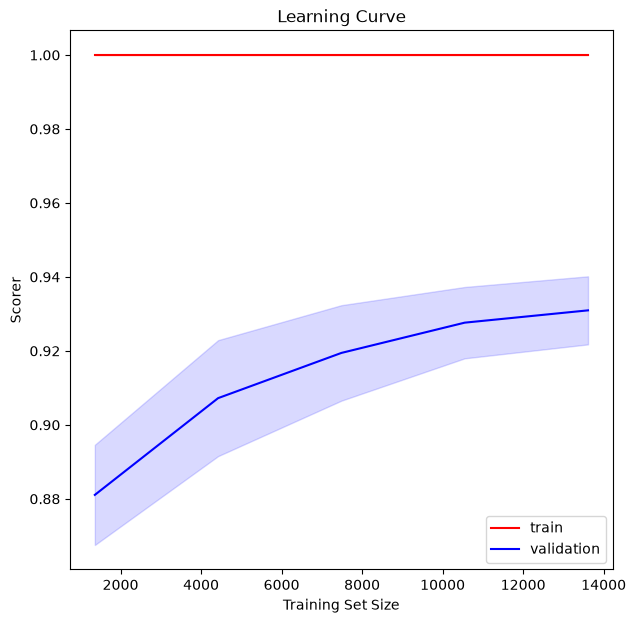

In [103]:
# plotting learning curve für best model
# computing learning curve
train_sizes, train_scores, test_scores = learning_curve(estimator=best_model, 
                                                        X=features_train, 
                                                        y=np.ravel(target_train), 
                                                        cv=cv, 
                                                        scoring=scoring["tpr_fpr_020"])

# computing mean scores of train and test data
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Standardabweichungen
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)


# plotting learning curve
plt.subplots(figsize=(7,7))

# Bereiche: Mittelwert +/- Standardabweichung
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    color='red',
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    color='blue',
    alpha=0.15
)

plt.plot(train_sizes, train_mean, label="train", color = 'red')
plt.plot(train_sizes, test_mean, label="validation", color = 'blue')

plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Scorer")
plt.legend(loc="best")

plt.show()

## Model Interpretation

In [106]:
importances = rf_pipe_bo_2.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
8,fAlpha,0.117
16,alpha_alignment,0.115
0,fLength,0.093
2,fSize,0.086
14,ellipse_area,0.076
13,width_length_ratio,0.060
1,fWidth,0.060
15,brightest_pixel_share,0.056
9,fDist,0.052
11,abs_fM3Long,0.047


In [108]:
# get feature names before PCA
feature_names = rf_pipe_bo_2.feature_names_in_


,Feature,Importance Mean,Importance Std
2,fSize,0.148,0.007
8,fAlpha,0.107,0.011
16,alpha_alignment,0.105,0.012
0,fLength,0.061,0.010
11,abs_fM3Long,0.049,0.007
13,width_length_ratio,0.040,0.007
14,ellipse_area,0.040,0.008
15,brightest_pixel_share,0.038,0.005
9,fDist,0.018,0.006
1,fWidth,0.014,0.005


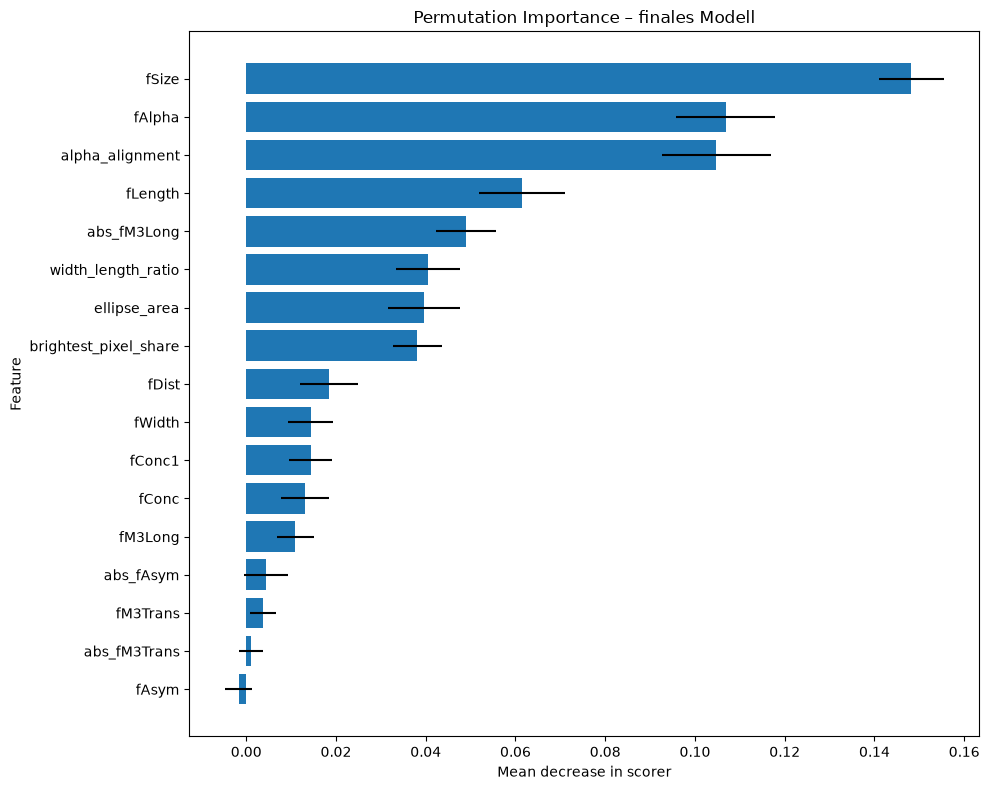

In [114]:
# Permutation Importance auf der kompletten Pipeline
perm_importance = permutation_importance(
    best_model,
    features_test_eng,
    target_test,
    n_repeats=50,
    random_state=42,
    scoring=scoring["tpr_fpr_020"],
    n_jobs=1
)

# Ergebnisse in DataFrame
perm_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
})

# Sortieren
perm_importance_df = perm_importance_df.sort_values(
    "Importance Mean",
    ascending=False
)

# Top 20 anzeigen
display(perm_importance_df.head(20))

# Plot
top_features = (
    perm_importance_df
    .head(20)
    .sort_values("Importance Mean")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance Mean"],
    xerr=top_features["Importance Std"]
)

plt.xlabel("Mean decrease in scorer")
plt.ylabel("Feature")
plt.title("Permutation Importance – finales Modell")

plt.tight_layout()
plt.show()